In [2]:
import pandas as pd

# Specify the URL to your CSV file
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0271EN-SkillsNetwork/labs/v1/m3/data/used_car_price_analysis.csv"
# Read the CSV file from the URL into a pandas DataFrame
df = pd.read_csv(file_url)

# Print the first 5 rows of the DataFrame
print(df.head())

     model  year transmission  mileage fuelType    tax   mpg  engineSize  \
0   Fiesta  2017    Automatic    15944   Petrol  150.0  57.7         1.0   
1    Focus  2018       Manual     9083   Petrol  150.0  57.7         1.0   
2    Focus  2017       Manual    12456   Petrol  150.0  57.7         1.0   
3   Fiesta  2019       Manual    10460   Petrol  145.0  40.3         1.5   
4   Fiesta  2019    Automatic     1482   Petrol  145.0  48.7         1.0   

   price  
0  12000  
1  14000  
2  13000  
3  17500  
4  16500  


In [3]:
# Convert non-numeric columns to numeric where possible
#for column in df.columns:
#    if df[column].dtype == 'object':
#        try:
#            df[column] = pd.to_numeric(df[column], errors='coerce')
#        except Exception as e:
#            print(f"Error converting column {column}: {e}")

# Identify columns with missing values
missing_columns = df.columns[df.isnull().any()].tolist()
print(f"Columns with missing values: {missing_columns}")

# Replace missing values with the mean of the column
for column in missing_columns:
    df[column].fillna(df[column].mean(), inplace=True)

# Remove duplicate entries
df.drop_duplicates(inplace=True)

# Print the first 5 rows after processing
print(df.head())

Columns with missing values: ['tax']
     model  year transmission  mileage fuelType    tax   mpg  engineSize  \
0   Fiesta  2017    Automatic    15944   Petrol  150.0  57.7         1.0   
1    Focus  2018       Manual     9083   Petrol  150.0  57.7         1.0   
2    Focus  2017       Manual    12456   Petrol  150.0  57.7         1.0   
3   Fiesta  2019       Manual    10460   Petrol  145.0  40.3         1.5   
4   Fiesta  2019    Automatic     1482   Petrol  145.0  48.7         1.0   

   price  
0  12000  
1  14000  
2  13000  
3  17500  
4  16500  


/var/folders/r3/k98zmw2d6pz1108mn6crmv980000gn/T/ipykernel_2014/3408120025.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)


In [4]:
# Identify the top 5 attributes with the highest correlation with the target attribute
target_attribute = 'price'  # Replace 'price' with your target attribute
correlation = df.select_dtypes(exclude=['object','category']).corr()[target_attribute].sort_values(ascending=False)
top_5_attributes = correlation.index[1:6].tolist()  # Exclude the target attribute itself
print(f"Top 5 attributes with highest correlation to {target_attribute}: {top_5_attributes}")

Top 5 attributes with highest correlation to price: ['year', 'engineSize', 'tax', 'mpg', 'mileage']


In [5]:
# Count the number of entries for each unique value of a specific attribute
attribute = 'fuelType'  # Replace 'make' with your specific attribute
value_counts = df[attribute].value_counts()
print(f"Counts of each unique value in {attribute}:\n{value_counts}")

Counts of each unique value in fuelType:
fuelType
Petrol      12081
Diesel       5706
Hybrid         22
Electric        2
Other           1
Name: count, dtype: int64


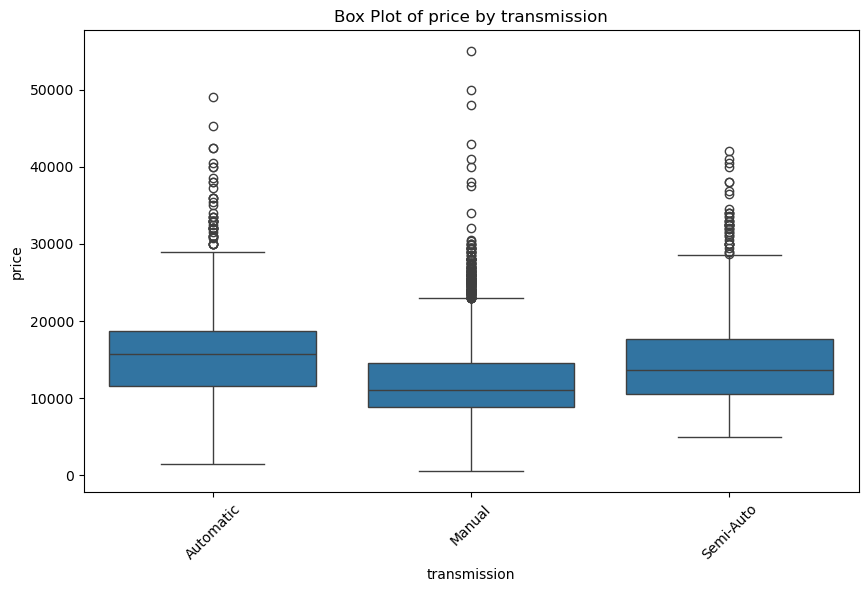

In [6]:
import seaborn as sns

import matplotlib.pyplot as plt

# Define source and target attributes
source_attribute = 'transmission'  # Replace with your source attribute
target_attribute = 'price'     # Replace with your target attribute

# Create a Seaborn box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=source_attribute, y=target_attribute, data=df)
plt.title(f'Box Plot of {target_attribute} by {source_attribute}')
plt.xlabel(source_attribute)
plt.ylabel(target_attribute)
plt.xticks(rotation=45)
plt.show()

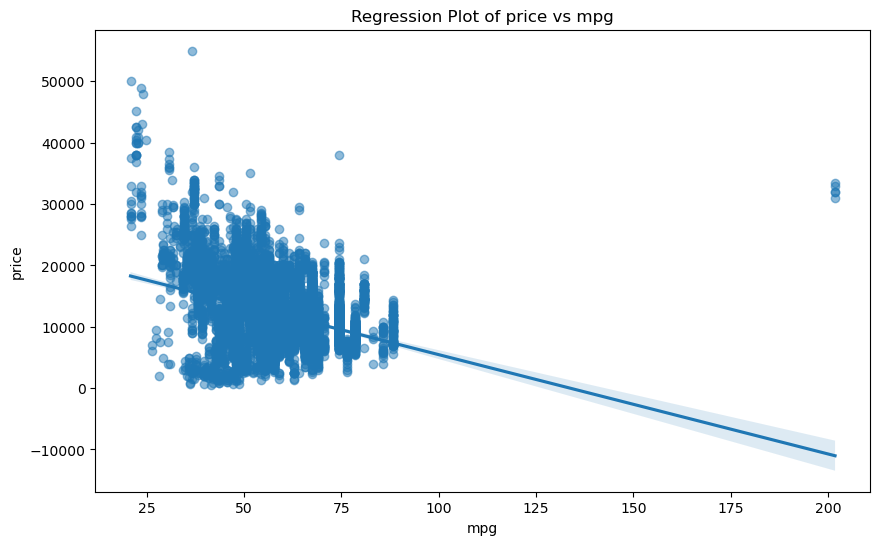

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define source and target attributes
source_attribute = 'mpg'  # Replace with your source attribute
target_attribute = 'price'   # Replace with your target attribute

# Create a Seaborn regression plot
plt.figure(figsize=(10, 6))
sns.regplot(x=source_attribute, y=target_attribute, data=df, scatter_kws={'alpha':0.5})
plt.title(f'Regression Plot of {target_attribute} vs {source_attribute}')
plt.xlabel(source_attribute)
plt.ylabel(target_attribute)
plt.show()

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define the feature and target variable
X = df[['mpg']]  # Replace 'mpg' with the actual column name for miles per gallon
y = df['price']  # Replace 'price' with the actual column name for price

# Fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Make predictions
y_pred = model.predict(X)

# Calculate R^2 and MSE
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

print(f"R^2: {r2}")
print(f"MSE: {mse}")

R^2: 0.1198980224962416
MSE: 19741690.809446193


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define the features and target variable
features = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
X = df[features]
y = df['price']  # Replace 'price' with the actual column name for price

# Fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Make predictions
y_pred = model.predict(X)

# Calculate R^2 and MSE
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

print(f"R^2: {r2}")
print(f"MSE: {mse}")

R^2: 0.7265379654547028
MSE: 6134065.224381679


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define the features and target variable
features = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
X = df[features]
y = df['price']  # Replace 'price' with the actual column name for price

# Create the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly_features', PolynomialFeatures(degree=2)),
    ('linear_model', LinearRegression())
])

# Fit the pipeline model
pipeline.fit(X, y)

# Make predictions
y_pred = pipeline.predict(X)

# Calculate R^2 and MSE
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

print(f"R^2: {r2}")
print(f"MSE: {mse}")

R^2: 0.7666619695239302
MSE: 5234038.06546274


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# Define the features and target variable
features = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
X = df[features]
y = df['price']  # Replace 'price' with the actual column name for price

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and fit the Ridge regression model
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train, y_train)

# Make predictions on the test data
y_test_pred = ridge_model.predict(X_test)

# Calculate R^2 using the test data
r2_test = r2_score(y_test, y_test_pred)

print(f"R^2 on test data: {r2_test}")

R^2 on test data: 0.691713444611314
